# ¿Puede un mapa de calor decirle a la policía dónde patrullar?

## Focalización del delito mediante datos geográficos y estimación de densidad por kernel

**Maestría en Inteligencia Analítica de Datos (MIAD) — Aprendizaje No Supervisado**
**Módulo 7: Análisis de Puntos Calientes Geográficos**

---

### Contexto del caso

La Policía Metropolitana de Bogotá evalúa adoptar un protocolo de **focalización del delito**
para concentrar el patrullaje en puntos calientes, en lugar de distribuirlo de manera uniforme.
La identificación de esos puntos calientes depende del procedimiento utilizado: un conteo por
barrio puede señalar unas zonas prioritarias, mientras que un mapa de densidad puede señalar otras.

Para evaluar las alternativas se utilizan datos georreferenciados de **homicidios y robos en
Chicago durante el verano de 2019**. El objetivo no es replicar la experiencia de Chicago, sino
identificar qué aprendizajes metodológicos pueden trasladarse a Bogotá.

### Preguntas que guían la entrega

1. ¿Qué procedimiento de focalización debería adoptar la Policía Metropolitana de Bogotá?
2. ¿Qué elementos del enfoque de focalización del delito son generalizables entre contextos urbanos distintos?

### Estructura del cuaderno

| Paso | Contenido |
|------|-----------|
| 0 | Configuración del entorno |
| 1 | Exploración de los datos y del problema de negocio |
| 2 | Correlación entre delitos |
| 3 | Visualización: conteo vs. conteo normalizado por superficie |
| 4 | Densidad según distancia al centro |
| 5 | Puntos calientes en el plano (KDE bivariado) |
| 6 | ¿Qué explica la ubicación de los puntos calientes? |
| 7 | Ranking de procedimientos, transferencia y recomendación |

### Integrantes del equipo

- *[Nombre 1]*
- *[Nombre 2]*
- *[Nombre 3]*

> **Reproducibilidad:** todo procedimiento con aleatoriedad usa `random_state=123` y los datos se
> cargan mediante rutas relativas a la carpeta `data`.

## Paso 0. Configuración del entorno

Antes de comenzar el análisis, cargamos las librerías, fijamos la semilla de reproducibilidad
(`random_state = 123`), definimos las rutas relativas a las carpetas `data` y `output`, y creamos
una función auxiliar `guardar_fig()` para exportar de forma homogénea todas las figuras que
sustentarán la presentación ejecutiva.

In [1]:
# ============================================================
# Paso 0. Configuración del entorno — Librerías
# ============================================================

# --- Librerías estándar ---
import os
import warnings

# --- Análisis de datos ---
import numpy as np
import pandas as pd

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Datos geográficos ---
import geopandas as gpd
from shapely.geometry import Point

# --- Distancias geográficas ---
from geopy.distance import geodesic

# --- Estimación de densidad ---
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
import statsmodels.api as sm

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# ============================================================
# Paso 0. Configuración del entorno — Parámetros y rutas
# ============================================================

# --- Configuración general ---
warnings.simplefilter("ignore")
RANDOM_STATE = 123

# Estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# --- Rutas relativas ---
DATA_DIR = "data"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUTA_DELITOS = os.path.join(DATA_DIR, "Chicago_delitos_verano_2019.csv")
RUTA_AREAS = os.path.join(DATA_DIR, "Areas_comunitarias_Chicago")

print("Entorno configurado correctamente.")
print(f"random_state = {RANDOM_STATE}")
print(f"Carpeta de datos:   {DATA_DIR}")
print(f"Carpeta de salidas: {OUTPUT_DIR}")

Entorno configurado correctamente.
random_state = 123
Carpeta de datos:   data
Carpeta de salidas: output


In [4]:
# ============================================================
# Paso 0. Configuración del entorno — Función auxiliar
# ============================================================

def guardar_fig(nombre, fig=None, dpi=150):
    """Guarda una figura en la carpeta output/ con formato homogéneo.

    Parámetros
    ----------
    nombre : str
        Nombre del archivo sin extensión (ej. '01_conteo_por_area').
    fig : matplotlib.figure.Figure, opcional
        Figura a guardar. Si es None, usa la figura activa.
    dpi : int
        Resolución de la imagen exportada.
    """
    if fig is None:
        fig = plt.gcf()
    ruta = os.path.join(OUTPUT_DIR, f"{nombre}.png")
    fig.savefig(ruta, dpi=dpi, bbox_inches="tight")
    print(f"Figura guardada en: {ruta}")


print("Función guardar_fig() lista.")

Función guardar_fig() lista.


## Paso 1. Exploración de los datos y del problema de negocio

En este paso cargamos las dos fuentes de información —los delitos georreferenciados y los polígonos
de las 77 áreas comunitarias de Chicago—, verificamos su calidad y las integramos mediante una
**unión espacial** (`sjoin`). A partir de esa integración construimos una tabla descriptiva por área
comunitaria y evaluamos el **primer procedimiento de focalización**: el ranking basado únicamente en
el conteo de delitos por barrio.

Discutiremos qué tan concentrado está el delito, si coinciden las áreas con más robos y más
homicidios, y qué información aporta y qué omite este primer procedimiento.

### 1.1. Carga y descripción de la base de delitos

In [5]:
# ------------------------------------------------------------
# 1.1. Carga de la base de delitos
# ------------------------------------------------------------

delitos = pd.read_csv(RUTA_DELITOS, parse_dates=["fecha"])

print("Dimensiones:", delitos.shape)
print("\nPrimeras filas:")
display(delitos.head())

print("\nTipos de dato:")
print(delitos.dtypes)

print("\nValores nulos por columna:")
print(delitos.isnull().sum())

print("\nConteo por tipo de crimen:")
print(delitos["tipo_crimen"].value_counts())

print("\nRango de fechas:")
print(delitos["fecha"].min(), "->", delitos["fecha"].max())

print("\nÁreas comunitarias:")
print("  únicas:", delitos["nro_area_comunitaria"].nunique(),
      "| mín:", delitos["nro_area_comunitaria"].min(),
      "| máx:", delitos["nro_area_comunitaria"].max())

Dimensiones: (17747, 5)

Primeras filas:


,fecha,tipo_crimen,nro_area_comunitaria,lat,lon
0,2019-06-01 05:07:00+00:00,homicidio,23,41.897950,-87.728625
1,2019-06-01 10:09:00+00:00,homicidio,71,41.753272,-87.648963
2,2019-06-01 12:46:00+00:00,homicidio,25,41.877622,-87.750728
3,2019-06-01 11:35:00+00:00,homicidio,16,41.960145,-87.699654
4,2019-06-02 09:39:00+00:00,homicidio,37,41.804773,-87.633256



Tipos de dato:
fecha                   datetime64[us, UTC]
tipo_crimen                             str
nro_area_comunitaria                  int64
lat                                 float64
lon                                 float64
dtype: object

Valores nulos por columna:
fecha                   0
tipo_crimen             0
nro_area_comunitaria    0
lat                     0
lon                     0
dtype: int64

Conteo por tipo de crimen:
tipo_crimen
robo         17603
homicidio      144
Name: count, dtype: int64

Rango de fechas:
2019-06-01 05:00:00+00:00 -> 2019-09-01 04:48:00+00:00

Áreas comunitarias:
  únicas: 77 | mín: 1 | máx: 77


**Análisis 1.1**

La base contiene **17.747 delitos** registrados entre el 1 de junio y el 1 de septiembre de 2019
(el verano de Chicago), sin valores faltantes en ninguna columna. Cada registro tiene fecha y hora,
tipo de delito, número de área comunitaria y coordenadas (latitud, longitud).

El hallazgo más relevante para todo el análisis posterior es el **fuerte desbalance entre los dos
tipos de delito**: se registran **17.603 robos** frente a apenas **144 homicidios**. Los robos son
122 veces más frecuentes que los homicidios. Esta diferencia tiene dos implicaciones metodológicas
que retomaremos más adelante:

- La evidencia para los robos es abundante y permitirá estimaciones de densidad estables; la de los
  homicidios es escasa, por lo que sus estimaciones serán más ruidosas y sensibles a las decisiones
  de suavizamiento.
- No sería adecuado agregar ambos delitos en una sola medida (por ejemplo, un conteo total), porque
  el resultado quedaría dominado por los robos y ocultaría por completo el patrón de los homicidios.

Los delitos cubren las **77 áreas comunitarias** de la ciudad (numeradas de 1 a 77), lo que confirma
que la variable `nro_area_comunitaria` podrá cruzarse con los polígonos administrativos.

### 1.2. Carga de los polígonos de las áreas comunitarias

In [6]:
# ------------------------------------------------------------
# 1.2. Carga de los polígonos de las áreas comunitarias
# ------------------------------------------------------------

areas = gpd.read_file(RUTA_AREAS)

print("Dimensiones:", areas.shape)
print("\nCRS:", areas.crs)
print("\nTipos de geometría:")
print(areas.geom_type.value_counts())

print("\nColumnas disponibles:")
print(list(areas.columns))

print("\nPrimeras filas (sin geometría):")
display(areas.drop(columns="geometry").head())

Dimensiones: (77, 10)

CRS: GEOGCS["WGS84(DD)",DATUM["WGS84",SPHEROID["WGS84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]

Tipos de geometría:
Polygon         76
MultiPolygon     1
Name: count, dtype: int64

Columnas disponibles:
['area', 'area_num_1', 'area_numbe', 'comarea', 'comarea_id', 'community', 'perimeter', 'shape_area', 'shape_len', 'geometry']

Primeras filas (sin geometría):


,area,area_num_1,area_numbe,comarea,comarea_id,community,perimeter,shape_area,shape_len
0,0.0,35,35,0.0,0.0,DOUGLAS,0.0,4.600462e+07,31027.054510
1,0.0,36,36,0.0,0.0,OAKLAND,0.0,1.691396e+07,19565.506153
2,0.0,37,37,0.0,0.0,FULLER PARK,0.0,1.991670e+07,25339.089750
3,0.0,38,38,0.0,0.0,GRAND BOULEVARD,0.0,4.849250e+07,28196.837157
4,0.0,39,39,0.0,0.0,KENWOOD,0.0,2.907174e+07,23325.167906


**Análisis 1.2**

El shapefile contiene los **77 polígonos** de las áreas comunitarias, en coordenadas geográficas
**WGS84 (grados decimales)**. Las geometrías son polígonos (76) y un multipolígono (1, un barrio
cuya frontera está dividida en varias partes).

De las diez columnas disponibles, las relevantes para el análisis son:

- **`area_numbe`**: número de área comunitaria (1 a 77), que permite cruzar con la base de delitos.
- **`community`**: nombre del barrio, útil para reportar resultados de forma legible.

El resto de columnas (`area`, `comarea`, `shape_area`, etc.) provienen del origen del archivo y no
las usaremos. Dado que el CRS está en grados, más adelante (Paso 3) tendremos que **reproyectar** a
un sistema en metros para poder calcular superficies correctamente.

### 1.3. Unión espacial entre delitos y áreas comunitarias

Convertimos la base de delitos en un `GeoDataFrame` y realizamos una **unión espacial** (`sjoin`)
que asigna a cada delito el polígono que lo contiene. Como los datos ya incluyen la columna
`nro_area_comunitaria`, aprovechamos para **verificar** que la asignación espacial coincide con la
que traía la fuente original: si ambas concuerdan, confirmamos que las coordenadas y las áreas son
consistentes entre sí.

In [7]:
# ------------------------------------------------------------
# 1.3. Unión espacial (sjoin) entre delitos y áreas comunitarias
# ------------------------------------------------------------

# Convertimos los delitos a GeoDataFrame usando lon/lat.
# El shapefile está en EPSG:4326, así que declaramos el mismo CRS.
delitos_geo = gpd.GeoDataFrame(
    delitos.copy(),
    geometry=gpd.points_from_xy(delitos["lon"], delitos["lat"]),
    crs="EPSG:4326",
)

# Homogeneizamos el CRS de las áreas a EPSG:4326 (evita conflictos por el WKT del .prj)
areas = areas.to_crs("EPSG:4326")

# Unión espacial: a cada delito le asignamos el polígono que lo contiene
delitos_union = gpd.sjoin(
    delitos_geo,
    areas[["area_numbe", "community", "geometry"]],
    how="left",
    predicate="within",
)

# El area_numbe viene como texto; lo pasamos a numérico para comparar
delitos_union["area_numbe"] = pd.to_numeric(delitos_union["area_numbe"], errors="coerce")

# --- Verificación ---
print("Delitos sin área asignada por sjoin:",
      delitos_union["area_numbe"].isna().sum())

coincide = (delitos_union["area_numbe"] == delitos_union["nro_area_comunitaria"])
print("Delitos donde sjoin coincide con nro_area_comunitaria:",
      f"{coincide.sum()} de {len(delitos_union)} "
      f"({100 * coincide.mean():.2f}%)")

print("\nDelitos que NO coinciden:", (~coincide).sum())

Delitos sin área asignada por sjoin: 72
Delitos donde sjoin coincide con nro_area_comunitaria: 17203 de 17747 (96.93%)

Delitos que NO coinciden: 544


In [8]:
# ------------------------------------------------------------
# 1.3b. Diagnóstico de las discrepancias del sjoin
# ------------------------------------------------------------

# ¿Los 72 sin asignar y las discrepancias afectan más a robos o a homicidios?
delitos_union["_coincide"] = (
    delitos_union["area_numbe"] == delitos_union["nro_area_comunitaria"]
)

print("Discrepancias por tipo de crimen:")
print(delitos_union.groupby("tipo_crimen")["_coincide"]
      .agg(total="size",
           coinciden="sum",
           pct_coincidencia=lambda s: f"{100*s.mean():.2f}%"))

print("\nDe los que no coinciden, ¿cuántos son por NaN (sin polígono) "
      "vs. por barrio vecino?")
no_coincide = delitos_union[~delitos_union["_coincide"]]
print("  Sin polígono (NaN):", no_coincide["area_numbe"].isna().sum())
print("  Barrio vecino:     ", no_coincide["area_numbe"].notna().sum())

Discrepancias por tipo de crimen:
             total  coinciden pct_coincidencia
tipo_crimen                                   
homicidio      144        141           97.92%
robo         17603      17062           96.93%

De los que no coinciden, ¿cuántos son por NaN (sin polígono) vs. por barrio vecino?
  Sin polígono (NaN): 72
  Barrio vecino:      472


**Análisis 1.3**

La unión espacial coincide con la columna `nro_area_comunitaria` de la fuente en el **96,93%** de los
casos. Las discrepancias se descomponen en:

- **472 delitos (2,7%)** asignados por `sjoin` a un barrio **vecino**: puntos que caen muy cerca de
  una frontera administrativa, donde una diferencia mínima en las coordenadas los ubica del otro lado
  del límite.
- **72 delitos (0,4%)** que **no cayeron dentro de ningún polígono**: puntos justo sobre un borde o
  ligeramente fuera por la precisión de las coordenadas, que el criterio estricto `within` no captura.

La coincidencia es **homogénea entre tipos de delito** (97,92% en homicidios y 96,93% en robos), lo
que descarta un sesgo sistemático: se trata de ruido de frontera, no de un error en la
georreferenciación. El alto nivel de acuerdo **valida que las coordenadas y las áreas comunitarias
son consistentes entre sí**.

**Decisión metodológica.** Para todos los conteos y análisis por área utilizamos la columna
`nro_area_comunitaria` provista por la fuente, por tres razones: (i) no descarta ningún delito —los 72
puntos sin polígono sí tienen su número de área—; (ii) corresponde a la clasificación oficial,
presumiblemente construida con las geometrías originales completas; y (iii) el `sjoin` ya cumplió su
propósito de verificación. Reservamos las geometrías del shapefile para los mapas y el cálculo de
superficies.

### 1.4. Tabla descriptiva por área comunitaria y ranking por conteo

Construimos una tabla con el número de robos y homicidios por área comunitaria. Este conteo constituye
el **primer procedimiento de focalización**: priorizar el patrullaje según el número absoluto de
delitos por barrio. Analizamos qué tan concentrado está el delito y si las áreas más afectadas por
robos coinciden con las de más homicidios.

In [9]:
# ------------------------------------------------------------
# 1.4. Tabla descriptiva por área comunitaria
# ------------------------------------------------------------

# Conteo de delitos por área y tipo, usando la columna oficial
conteo = (
    delitos.groupby(["nro_area_comunitaria", "tipo_crimen"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Agregamos el nombre del barrio (desde el shapefile)
areas_nombres = areas.copy()
areas_nombres["area_numbe"] = pd.to_numeric(areas_nombres["area_numbe"])
conteo = conteo.merge(
    areas_nombres[["area_numbe", "community"]],
    left_on="nro_area_comunitaria",
    right_on="area_numbe",
    how="left",
).drop(columns="area_numbe")

# Reordenamos columnas
conteo = conteo[["nro_area_comunitaria", "community", "robo", "homicidio"]]

print("Tabla de conteo por área (primeras filas):")
display(conteo.head())

print("\nEstadísticas descriptivas de los conteos por área:")
display(conteo[["robo", "homicidio"]].describe())

# --- Concentración del delito ---
total_robos = conteo["robo"].sum()
total_homi = conteo["homicidio"].sum()

top10_robo = conteo.nlargest(10, "robo")
top10_homi = conteo.nlargest(10, "homicidio")

print(f"\nLas 10 áreas con más robos concentran "
      f"{100*top10_robo['robo'].sum()/total_robos:.1f}% de todos los robos.")
print(f"Las 10 áreas con más homicidios concentran "
      f"{100*top10_homi['homicidio'].sum()/total_homi:.1f}% de todos los homicidios.")

print("\nTop 10 áreas por ROBOS:")
display(top10_robo[["nro_area_comunitaria", "community", "robo", "homicidio"]])

print("\nTop 10 áreas por HOMICIDIOS:")
display(top10_homi[["nro_area_comunitaria", "community", "robo", "homicidio"]])

# --- ¿Coinciden los rankings? ---
set_robo = set(top10_robo["nro_area_comunitaria"])
set_homi = set(top10_homi["nro_area_comunitaria"])
print(f"\nÁreas presentes en ambos Top 10: {len(set_robo & set_homi)} de 10")
print("Áreas comunes:", sorted(set_robo & set_homi))

Tabla de conteo por área (primeras filas):


,nro_area_comunitaria,community,robo,homicidio
0,1,ROGERS PARK,375,2
1,2,WEST RIDGE,280,0
2,3,UPTOWN,266,0
3,4,LINCOLN SQUARE,169,0
4,5,NORTH CENTER,99,0



Estadísticas descriptivas de los conteos por área:


,robo,homicidio
count,77.000000,77.000000
mean,228.610390,1.870130
std,284.677664,3.079434
min,12.000000,0.000000
25%,75.000000,0.000000
50%,147.000000,0.000000
75%,266.000000,2.000000
max,1589.000000,15.000000



Las 10 áreas con más robos concentran 46.3% de todos los robos.
Las 10 áreas con más homicidios concentran 58.3% de todos los homicidios.

Top 10 áreas por ROBOS:


,nro_area_comunitaria,community,robo,homicidio
31,32,LOOP,1589,0
7,8,NEAR NORTH SIDE,1559,0
27,28,NEAR WEST SIDE,912,2
23,24,WEST TOWN,798,1
5,6,LAKE VIEW,762,1
24,25,AUSTIN,671,15
6,7,LINCOLN PARK,522,3
21,22,LOGAN SQUARE,520,0
43,44,CHATHAM,420,4
42,43,SOUTH SHORE,397,6



Top 10 áreas por HOMICIDIOS:


,nro_area_comunitaria,community,robo,homicidio
24,25,AUSTIN,671,15
22,23,HUMBOLDT PARK,319,12
28,29,NORTH LAWNDALE,277,12
68,69,GREATER GRAND CROSSING,289,9
48,49,ROSELAND,270,7
26,27,EAST GARFIELD PARK,235,6
42,43,SOUTH SHORE,397,6
45,46,SOUTH CHICAGO,153,6
65,66,CHICAGO LAWN,270,6
25,26,WEST GARFIELD PARK,142,5



Áreas presentes en ambos Top 10: 2 de 10
Áreas comunes: [25, 43]


**Análisis 1.4**

**Concentración del delito.** El delito está fuertemente concentrado en el territorio. Las 10 áreas
(de 77) con más robos acumulan el **46,3%** de todos los robos, y las 10 con más homicidios acumulan
el **58,3%** de los homicidios. La dispersión de los conteos lo confirma: los robos por área van de
12 a 1.589 (media 229, mediana 147), y los homicidios de 0 a 15, con más de la mitad de las áreas sin
ningún homicidio en todo el verano (mediana = 0). Esta concentración es, en sí misma, el argumento
que justifica evaluar una estrategia de focalización frente a un patrullaje uniforme.

**Robos y homicidios NO coinciden geográficamente.** Este es el hallazgo más importante del paso.
De las 10 áreas prioritarias por robos y las 10 por homicidios, **solo 2 coinciden** (Austin y South
Shore). Los robos se concentran en el centro y zonas afluentes —Loop (1.589) y Near North Side
(1.559) encabezan con amplio margen—, coherente con áreas de alta actividad comercial, flujo de
personas y bienes. Los homicidios, en cambio, se concentran en áreas del oeste y sur —Austin (15),
Humboldt Park (12), North Lawndale (12)—, con conteos de robos mucho menores. **Austin es el único
barrio que aparece de forma prominente en ambas listas.**

**Implicaciones para la focalización por conteo.** Un ranking basado únicamente en conteos induciría
a patrullar el centro de la ciudad, porque los robos —122 veces más frecuentes que los homicidios—
dominan cualquier medida agregada. Esto dejaría desatendidas las zonas de mayor violencia letal. El
procedimiento por conteo **aporta** una primera priorización simple y transparente, pero **omite**
tres cosas: (i) que los dos delitos tienen geografías distintas y requieren mapas separados; (ii) que
las áreas comunitarias tienen tamaños muy diferentes, por lo que un conteo alto puede reflejar
simplemente un barrio más grande; y (iii) que trabaja a la escala gruesa
del barrio, sin distinguir dónde dentro de cada área se concentra el delito.

### 1.5. Mapa de referencia de las áreas comunitarias

Generamos un **mapa interactivo** (folium) que permite identificar cada área comunitaria por su nombre
al pasar el cursor, y un **mapa estático** (GeoPandas) que servirá de referencia geográfica en la
presentación. Ambos muestran la división administrativa de Chicago en sus 77 áreas comunitarias.

In [10]:
# ------------------------------------------------------------
# 1.5a. Mapa interactivo de las áreas comunitarias (folium)
# ------------------------------------------------------------

import folium

# Centro aproximado de Chicago
centro_chi = [areas.geometry.centroid.y.mean(),
              areas.geometry.centroid.x.mean()]

mapa_areas = folium.Map(location=centro_chi, tiles="OpenStreetMap", zoom_start=10)

# Agregamos los polígonos con el nombre del barrio en tooltip
folium.GeoJson(
    areas,
    name="Áreas comunitarias",
    style_function=lambda x: {
        "fillColor": "#3186cc",
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.15,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["area_numbe", "community"],
        aliases=["N° área:", "Barrio:"],
    ),
).add_to(mapa_areas)

mapa_areas

Figura guardada en: output\01_areas_comunitarias_referencia.png


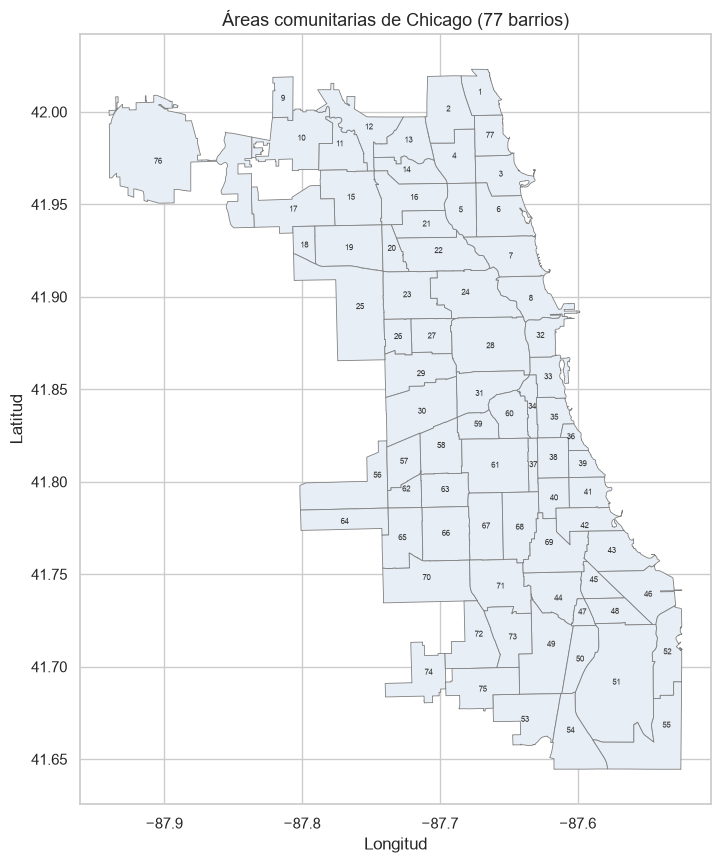

In [12]:
# ------------------------------------------------------------
# 1.5b. Mapa estático de referencia
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 10))

areas.plot(ax=ax, color="#e8eef5", edgecolor="gray", linewidth=0.6)

# Etiquetamos cada área con su número en el centroide
for _, fila in areas.iterrows():
    c = fila.geometry.representative_point()
    ax.annotate(fila["area_numbe"], xy=(c.x, c.y),
                ha="center", va="center", fontsize=6, color="#333333")

ax.set_title("Áreas comunitarias de Chicago (77 barrios)", fontsize=13)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

guardar_fig("01_areas_comunitarias_referencia")
plt.show()

### 1.6. Características espaciales relevantes

Antes de avanzar, registramos tres características espaciales de los datos que condicionan los
procedimientos posteriores:

1. **Desbalance entre delitos (17.603 robos vs. 144 homicidios).** La evidencia de homicidios es
   escasa, por lo que sus estimaciones de densidad serán más ruidosas y exigirán mayor suavizamiento.
   Impide agregar ambos delitos en una sola medida.

2. **Geografías distintas.** Robos y homicidios se concentran en zonas diferentes de la ciudad (solo
   2 de 10 áreas prioritarias coinciden), lo que obliga a analizarlos y mapearlos por separado.

3. **Áreas comunitarias de tamaño heterogéneo.** Como se aprecia en el mapa de referencia, los
   barrios tienen superficies muy distintas. Un conteo absoluto por área puede confundir "más delito"
   con "barrio más grande"; por eso en el Paso 3 normalizaremos por superficie, lo que requiere
   trabajar en un sistema de coordenadas en metros.

Estas observaciones justifican pasar de un conteo por barrio (procedimiento grueso) a métodos que
capturen mejor la estructura espacial continua del delito (Pasos 3 a 5).

## Paso 2. Correlación entre delitos

Analizamos la relación entre el número de robos y homicidios por área comunitaria mediante una gráfica
de dispersión con recta de regresión. Cuantificamos la asociación, identificamos las áreas que se
apartan del patrón general y examinamos qué implica esta relación para el diseño de una estrategia de
focalización.

### 2.1. Dispersión robos vs. homicidios con recta de regresión

Correlación de Pearson:  r = 0.171  (p = 1.37e-01)
Correlación de Spearman: rho = 0.464  (p = 2.13e-05)

Recta de regresión: homicidios = 1.447 + 0.00185 * robos
R² = 0.029
Figura guardada en: output\02_correlacion_robos_homicidios.png


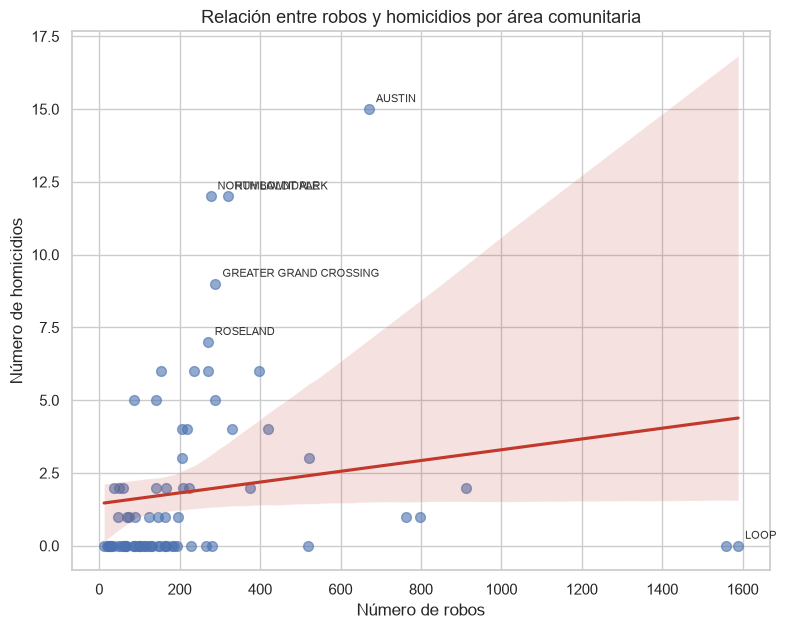

In [13]:
# ------------------------------------------------------------
# 2.1. Correlación entre robos y homicidios por área
# ------------------------------------------------------------

from scipy import stats

x = conteo["robo"]
y = conteo["homicidio"]

# Correlaciones
pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

# Recta de regresión (homicidios ~ robos)
pendiente, intercepto, r_val, p_val, err = stats.linregress(x, y)

print(f"Correlación de Pearson:  r = {pearson_r:.3f}  (p = {pearson_p:.2e})")
print(f"Correlación de Spearman: rho = {spearman_r:.3f}  (p = {spearman_p:.2e})")
print(f"\nRecta de regresión: homicidios = {intercepto:.3f} + {pendiente:.5f} * robos")
print(f"R² = {r_val**2:.3f}")

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(9, 7))

sns.regplot(x=x, y=y, ax=ax,
            scatter_kws={"alpha": 0.6, "s": 50},
            line_kws={"color": "#c0392b"})

# Etiquetamos las áreas más notables (outliers)
conteo["_resid"] = y - (intercepto + pendiente * x)
outliers = conteo.reindex(conteo["_resid"].abs().sort_values(ascending=False).index).head(6)

for _, fila in outliers.iterrows():
    ax.annotate(fila["community"],
                xy=(fila["robo"], fila["homicidio"]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=8, color="#333333")

ax.set_title("Relación entre robos y homicidios por área comunitaria", fontsize=13)
ax.set_xlabel("Número de robos")
ax.set_ylabel("Número de homicidios")

guardar_fig("02_correlacion_robos_homicidios")
plt.show()

**Análisis 2.1**

**La relación entre robos y homicidios es débil.** La correlación lineal de Pearson es prácticamente
nula y no significativa (r = 0,171; p = 0,14), y la regresión confirma que los robos explican apenas
el **2,9%** de la variación en homicidios (R² = 0,029), con una recta casi plana. La correlación de
Spearman, basada en rangos, es moderada y significativa (rho = 0,464; p < 0,001), lo que indica una
asociación monótona suave: barrios con más actividad delictiva de un tipo tienden a tener *algo* del
otro, pero la relación está lejos de ser fuerte.

**Por qué difieren Pearson y Spearman.** La brecha entre ambas medidas es informativa. Pearson es
sensible a los valores extremos, y el gráfico muestra varios: **Loop** y **Near North Side** (abajo a
la derecha) concentran gran cantidad de robos con **cero homicidios**, mientras que **Austin** (arriba)
tiene 15 homicidios con robos apenas moderados. Estos casos, opuestos entre sí, tiran la correlación
lineal hacia cero. Spearman, al trabajar con rangos, es robusto a ellos y captura la tendencia general.

**Áreas que se apartan del patrón.** Los barrios más atípicos son de dos tipos:
- **Alto en homicidios, moderado en robos** (oeste y sur): Austin, Humboldt Park, North Lawndale,
  Greater Grand Crossing, Roseland. Son las zonas de violencia letal que un mapa de robos ignoraría.
- **Alto en robos, nulo en homicidios** (centro): Loop, Near North Side. Zonas comerciales de alto
  flujo donde el robo es frecuente pero la violencia letal, rara.

**Implicaciones para la focalización.** Robos y homicidios son fenómenos espacialmente distintos.
Agregarlos en una sola medida sería un error: la suma quedaría dominada por los robos (122 veces más
numerosos) y borraría por completo el patrón de los homicidios, dirigiendo el patrullaje al centro y
desatendiendo las zonas de mayor violencia. La evidencia también es asimétrica en solidez: con 17.603
robos las estimaciones serán estables, mientras que con 144 homicidios —muchos barrios con cero— serán
frágiles y sensibles al método. **Conclusión inicial: los dos delitos deben analizarse, mapearse y focalizarse
por separado.**

### 2.2. Ubicación geográfica de las áreas atípicas

Localizamos en el mapa las áreas que más se apartan de la relación general entre robos y homicidios,
distinguiendo dos tipos: las de **alta violencia letal** (más homicidios de los que predice su nivel de
robos) y las de **alto volumen de robos** (concentraciones de robo sin violencia letal proporcional).

Figura guardada en: output\03_outliers_mapa.png


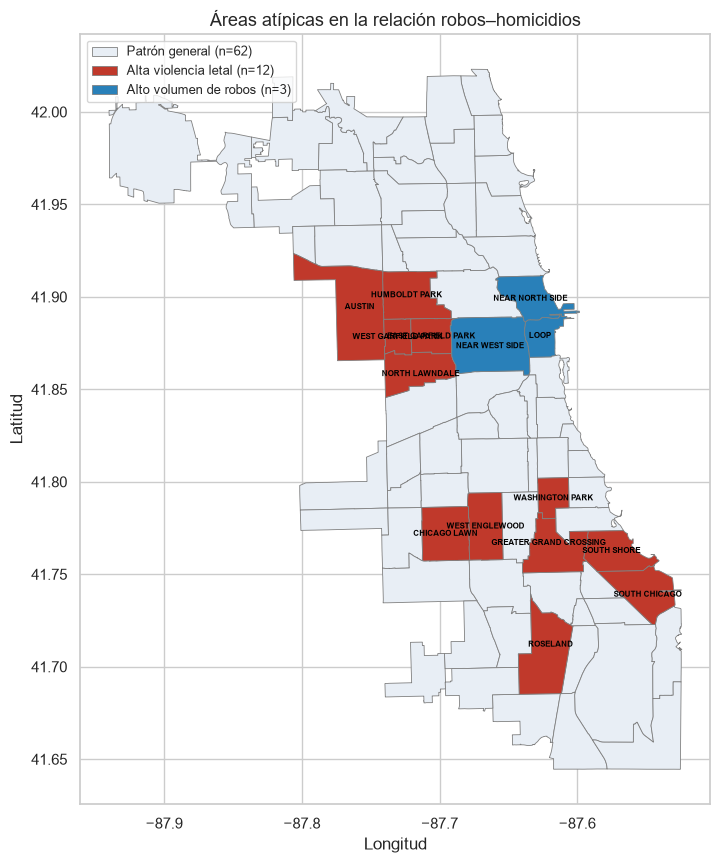

Barrios de alta violencia letal:
             community  robo  homicidio    _resid
                AUSTIN   671         15 12.310969
        NORTH LAWNDALE   277         12 10.040297
         HUMBOLDT PARK   319         12  9.962551
GREATER GRAND CROSSING   289          9  7.018084
              ROSELAND   270          7  5.053254
         SOUTH CHICAGO   153          6  4.269831
    EAST GARFIELD PARK   235          6  4.118042
          CHICAGO LAWN   270          6  4.053254
           SOUTH SHORE   397          6  3.818167
       WASHINGTON PARK    87          5  3.392003
    WEST GARFIELD PARK   142          5  3.290193
        WEST ENGLEWOOD   289          5  3.018084

Barrios de alto volumen de robos:
      community  robo  homicidio
           LOOP  1589          0
NEAR NORTH SIDE  1559          0
 NEAR WEST SIDE   912          2


In [16]:
# ------------------------------------------------------------
# 2.2. Mapa de las áreas atípicas
# ------------------------------------------------------------

# Unimos residuos y conteos al GeoDataFrame de áreas.
# El shapefile ya tiene 'community', así que traemos solo lo que falta desde conteo.
areas_map = areas.copy()
areas_map["area_numbe"] = pd.to_numeric(areas_map["area_numbe"])
areas_map = areas_map.merge(
    conteo[["nro_area_comunitaria", "robo", "homicidio", "_resid"]],
    left_on="area_numbe",
    right_on="nro_area_comunitaria",
    how="left",
)

# Clasificamos los outliers según el signo del residuo
umbral_resid = 3          # homicidios por encima de lo predicho
umbral_robos = 800        # robos absolutos muy altos

def clasificar(fila):
    if fila["_resid"] >= umbral_resid:
        return "Alta violencia letal"
    elif fila["robo"] >= umbral_robos:
        return "Alto volumen de robos"
    else:
        return "Patrón general"

areas_map["grupo"] = areas_map.apply(clasificar, axis=1)

# --- Mapa ---
fig, ax = plt.subplots(figsize=(9, 10))

colores = {
    "Patrón general": "#e8eef5",
    "Alta violencia letal": "#c0392b",
    "Alto volumen de robos": "#2980b9",
}

for grupo, color in colores.items():
    subset = areas_map[areas_map["grupo"] == grupo]
    subset.plot(ax=ax, color=color, edgecolor="gray", linewidth=0.6,
                label=f"{grupo} (n={len(subset)})")

# Etiquetamos los barrios resaltados (usamos 'community' del shapefile)
for _, fila in areas_map[areas_map["grupo"] != "Patrón general"].iterrows():
    c = fila.geometry.representative_point()
    ax.annotate(fila["community"], xy=(c.x, c.y),
                ha="center", va="center", fontsize=6, color="black",
                fontweight="bold")

ax.set_title("Áreas atípicas en la relación robos–homicidios", fontsize=13)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(loc="upper left", fontsize=9)

guardar_fig("03_outliers_mapa")
plt.show()

# Resumen de los barrios resaltados
print("Barrios de alta violencia letal:")
print(areas_map[areas_map["grupo"] == "Alta violencia letal"]
      [["community", "robo", "homicidio", "_resid"]]
      .sort_values("_resid", ascending=False).to_string(index=False))

print("\nBarrios de alto volumen de robos:")
print(areas_map[areas_map["grupo"] == "Alto volumen de robos"]
      [["community", "robo", "homicidio"]]
      .sort_values("robo", ascending=False).to_string(index=False))

**Análisis 2.2**

El mapa confirma visualmente la separación geográfica entre los dos delitos:

- **Alta violencia letal (12 áreas, en rojo):** forman una banda continua en el **oeste** de la ciudad
  (Austin, Humboldt Park, East y West Garfield Park, North Lawndale) y en el **sur** (Greater Grand
  Crossing, South Shore, South Chicago, Roseland, Chicago Lawn, Washington Park). Son barrios con más
  homicidios de los que predeciría su nivel de robos.

- **Alto volumen de robos (3 áreas, en azul):** un bloque compacto en el **centro-noreste**, sobre la
  costa del lago Michigan (Loop, Near North Side, Near West Side). Corresponde al distrito comercial y
  financiero, con gran flujo de personas y bienes.

Los dos grupos **casi no se tocan**: la violencia letal se agrupa en la periferia oeste y sur, mientras
que los robos se concentran en el núcleo comercial. Esta disociación espacial es coherente con la baja
correlación cuantificada en 2.1 y con la intuición criminológica: los robos siguen la actividad
económica y el flujo de personas, mientras que los homicidios tienden a concentrarse en zonas con menor
vigilancia informal ("menos ojos en la calle").

**Consecuencia para la focalización.** Una estrategia de patrullaje no puede basarse en un único mapa.
Un mapa de robos enviaría los recursos al centro; uno de homicidios, al oeste y sur. Ambos son válidos,
pero responden a objetivos distintos, y la decisión de qué priorizar es tanto técnica como de política
pública.

## Paso 3. Visualización: conteo vs. conteo normalizado por superficie

Comparamos dos procedimientos de focalización basados en el mapa por áreas: el **conteo absoluto** de
delitos por barrio y el **conteo normalizado por superficie** (delitos por km²). Para calcular las
superficies correctamente reproyectamos las geometrías a un sistema de coordenadas en metros, ya que el
shapefile original está en grados. Evaluamos si la normalización cambia la identificación de las áreas
prioritarias.

### 3.1. Reproyección y cálculo de superficies

El shapefile está en WGS84 (grados). Calcular áreas directamente en grados produce valores sin
significado físico, porque un grado de longitud y uno de latitud no miden lo mismo. Reproyectamos a
**EPSG:26971 (NAD83 / Illinois East)**, un sistema de coordenadas proyectado en metros diseñado para la
región de Chicago, que minimiza la distorsión de áreas y distancias localmente.

In [17]:
# ------------------------------------------------------------
# 3.1. Reproyección a un CRS en metros y cálculo de superficies
# ------------------------------------------------------------

# EPSG:26971 = NAD83 / Illinois East (unidades en metros), apropiado para Chicago
CRS_METROS = 26971

areas_m = areas.to_crs(CRS_METROS)

# Superficie en km² (el área en EPSG:26971 sale en m²)
areas_m["area_km2"] = areas_m.geometry.area / 1e6

print("CRS reproyectado:", areas_m.crs.name)
print("\nSuperficie de los barrios (km²):")
print(areas_m["area_km2"].describe())

print("\nBarrio más grande y más pequeño:")
mas_grande = areas_m.loc[areas_m["area_km2"].idxmax()]
mas_chico = areas_m.loc[areas_m["area_km2"].idxmin()]
print(f"  Mayor:  {mas_grande['community']} = {mas_grande['area_km2']:.2f} km²")
print(f"  Menor:  {mas_chico['community']} = {mas_chico['area_km2']:.2f} km²")
print(f"  Razón grande/chico: {mas_grande['area_km2']/mas_chico['area_km2']:.1f}x")

CRS reproyectado: NAD83 / Illinois East

Superficie de los barrios (km²):
count    77.000000
mean      7.768075
std       5.104695
min       1.571365
25%       4.623769
50%       7.398433
75%       9.183797
max      34.544797
Name: area_km2, dtype: float64

Barrio más grande y más pequeño:
  Mayor:  OHARE = 34.54 km²
  Menor:  OAKLAND = 1.57 km²
  Razón grande/chico: 22.0x


**Análisis 3.1**

Tras reproyectar a **NAD83 / Illinois East (metros)**, las 77 áreas comunitarias tienen superficies muy
dispares: de **1,57 km²** (Oakland) a **34,54 km²** (O'Hare, el barrio del aeropuerto), una razón de
**22 a 1**. La superficie mediana es de 7,4 km².

Esta heterogeneidad es la razón técnica por la que el conteo absoluto puede ser engañoso: un barrio
grande puede acumular muchos delitos simplemente por su tamaño, no por ser más peligroso por unidad de
área. Normalizar por superficie (delitos por km²) corrige este efecto y responde a una pregunta
distinta —dónde es más *intenso* el delito, no solo dónde hay *más* en total—, lo que puede alterar el
ranking de áreas prioritarias. Lo verificamos a continuación.

### 3.2. Conteo absoluto vs. densidad por superficie (robos)

Comparamos dos mapas de robos: el conteo absoluto por área y el conteo normalizado por superficie
(robos por km²). Nos centramos primero en los robos, que constituyen la evidencia más sólida
(17.603 registros frente a 144 homicidios).

Figura guardada en: output\04_robos_conteo_vs_densidad.png


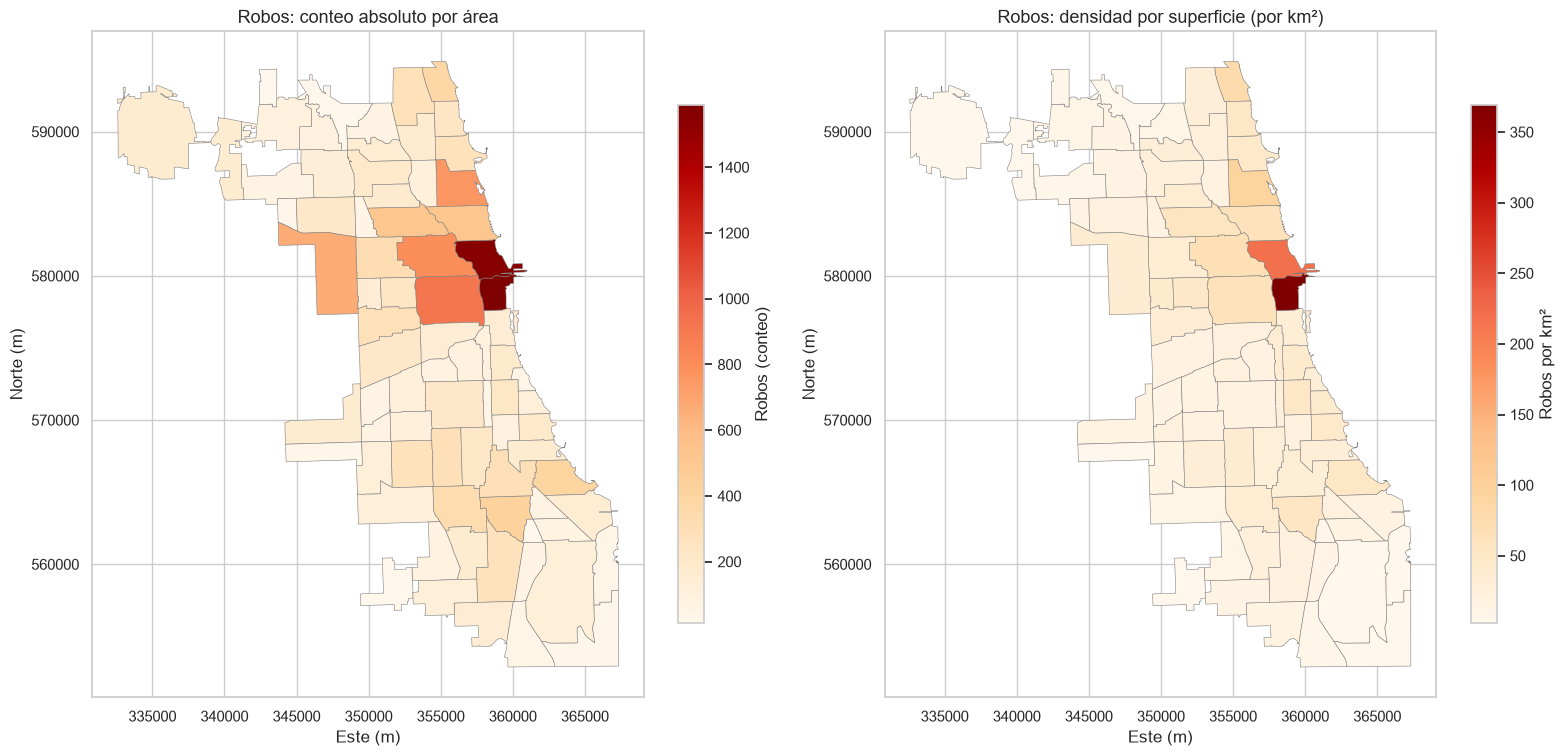

Top 5 por CONTEO de robos:
      community  robo   robo_km2
           LOOP  1589 369.128661
NEAR NORTH SIDE  1559 218.854557
 NEAR WEST SIDE   912  61.937625
      WEST TOWN   798  67.335925
      LAKE VIEW   762  94.044440

Top 5 por DENSIDAD de robos (por km²):
      community  robo   robo_km2
           LOOP  1589 369.128661
NEAR NORTH SIDE  1559 218.854557
      LAKE VIEW   762  94.044440
    ROGERS PARK   375  78.744790
      WEST TOWN   798  67.335925

Áreas en ambos Top 5: 4 -> {'LOOP', 'LAKE VIEW', 'NEAR NORTH SIDE', 'WEST TOWN'}


In [18]:
# ------------------------------------------------------------
# 3.2. Mapas comparativos de robos: conteo vs. densidad
# ------------------------------------------------------------

# Añadimos los conteos al GeoDataFrame reproyectado
areas_m["area_numbe"] = pd.to_numeric(areas_m["area_numbe"])
areas_viz = areas_m.merge(
    conteo[["nro_area_comunitaria", "robo", "homicidio"]],
    left_on="area_numbe",
    right_on="nro_area_comunitaria",
    how="left",
)

# Densidades por km²
areas_viz["robo_km2"] = areas_viz["robo"] / areas_viz["area_km2"]
areas_viz["homi_km2"] = areas_viz["homicidio"] / areas_viz["area_km2"]

# --- Mapas lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Conteo absoluto
areas_viz.plot(column="robo", ax=axes[0], legend=True, cmap="OrRd",
               edgecolor="gray", linewidth=0.4,
               legend_kwds={"label": "Robos (conteo)", "shrink": 0.6})
axes[0].set_title("Robos: conteo absoluto por área", fontsize=13)
axes[0].set_xlabel("Este (m)")
axes[0].set_ylabel("Norte (m)")

# Densidad por km²
areas_viz.plot(column="robo_km2", ax=axes[1], legend=True, cmap="OrRd",
               edgecolor="gray", linewidth=0.4,
               legend_kwds={"label": "Robos por km²", "shrink": 0.6})
axes[1].set_title("Robos: densidad por superficie (por km²)", fontsize=13)
axes[1].set_xlabel("Este (m)")
axes[1].set_ylabel("Norte (m)")

plt.tight_layout()
guardar_fig("04_robos_conteo_vs_densidad")
plt.show()

# --- ¿Cambia el ranking? ---
top5_conteo = areas_viz.nlargest(5, "robo")[["community", "robo", "robo_km2"]]
top5_densidad = areas_viz.nlargest(5, "robo_km2")[["community", "robo", "robo_km2"]]

print("Top 5 por CONTEO de robos:")
print(top5_conteo.to_string(index=False))
print("\nTop 5 por DENSIDAD de robos (por km²):")
print(top5_densidad.to_string(index=False))

comunes = set(top5_conteo["community"]) & set(top5_densidad["community"])
print(f"\nÁreas en ambos Top 5: {len(comunes)} -> {comunes}")

**Análisis 3.2**

**¿Cambia la identificación de áreas prioritarias?** Parcialmente. El Top 5 por conteo y por densidad
comparten 4 de 5 áreas (Loop, Near North Side, West Town y Lake View). El cambio se da en el quinto
puesto: **Near West Side sale** del ranking al normalizar —tiene muchos robos (912) pero es un área
grande, lo que diluye su densidad— y **entra Rogers Park**, que con apenas 375 robos absolutos (lejos
del Top 5 por conteo) alcanza 78,7 robos/km² por ser un barrio pequeño. Es justamente el caso que la
normalización busca revelar: intensidad alta por unidad de área que el conteo absoluto oculta.

**Qué significa normalizar por superficie.** Pasar de "cuántos robos hay" a "qué tan denso es el robo
por km²" responde a una pregunta distinta. El conteo mide la carga total de trabajo policial en un
barrio; la densidad mide la concentración espacial del delito. Para el Loop la diferencia es enorme:
1.589 robos en un área compacta se traducen en 369 robos/km², la densidad más alta de la ciudad con
amplio margen.

**Otros denominadores relevantes.** La superficie no es el único denominador posible. Para una decisión
de patrullaje podrían ser más pertinentes la **población residente**, la **población flotante** (el
Loop se vacía de noche y se llena de día), la **longitud de vías** o el **número de establecimientos
comerciales**. Cada denominador responde a una pregunta operativa distinta y cambiaría el ranking.

**Escala de decisión.** Este procedimiento opera a la escala gruesa del barrio (77 unidades). Permite
una asignación macro de recursos entre áreas, pero **no indica dónde dentro de cada barrio** patrullar.
Además, el resultado depende de las unidades territoriales elegidas (el problema de la unidad de área
modificable): si Chicago se dividiera en otras fronteras, los rankings podrían cambiar. Esta limitación
motiva pasar a métodos de densidad continua (Pasos 4 y 5) que no dependen de fronteras administrativas.

### 3.3. Conteo absoluto vs. densidad por superficie (homicidios)

Replicamos la comparación para los homicidios. A diferencia de los robos, la evidencia aquí es escasa
(144 homicidios, con más de la mitad de las áreas en cero), por lo que los mapas deben interpretarse
con cautela: pequeñas diferencias en el conteo se amplifican al normalizar por superficie.

Figura guardada en: output\05_homicidios_conteo_vs_densidad.png


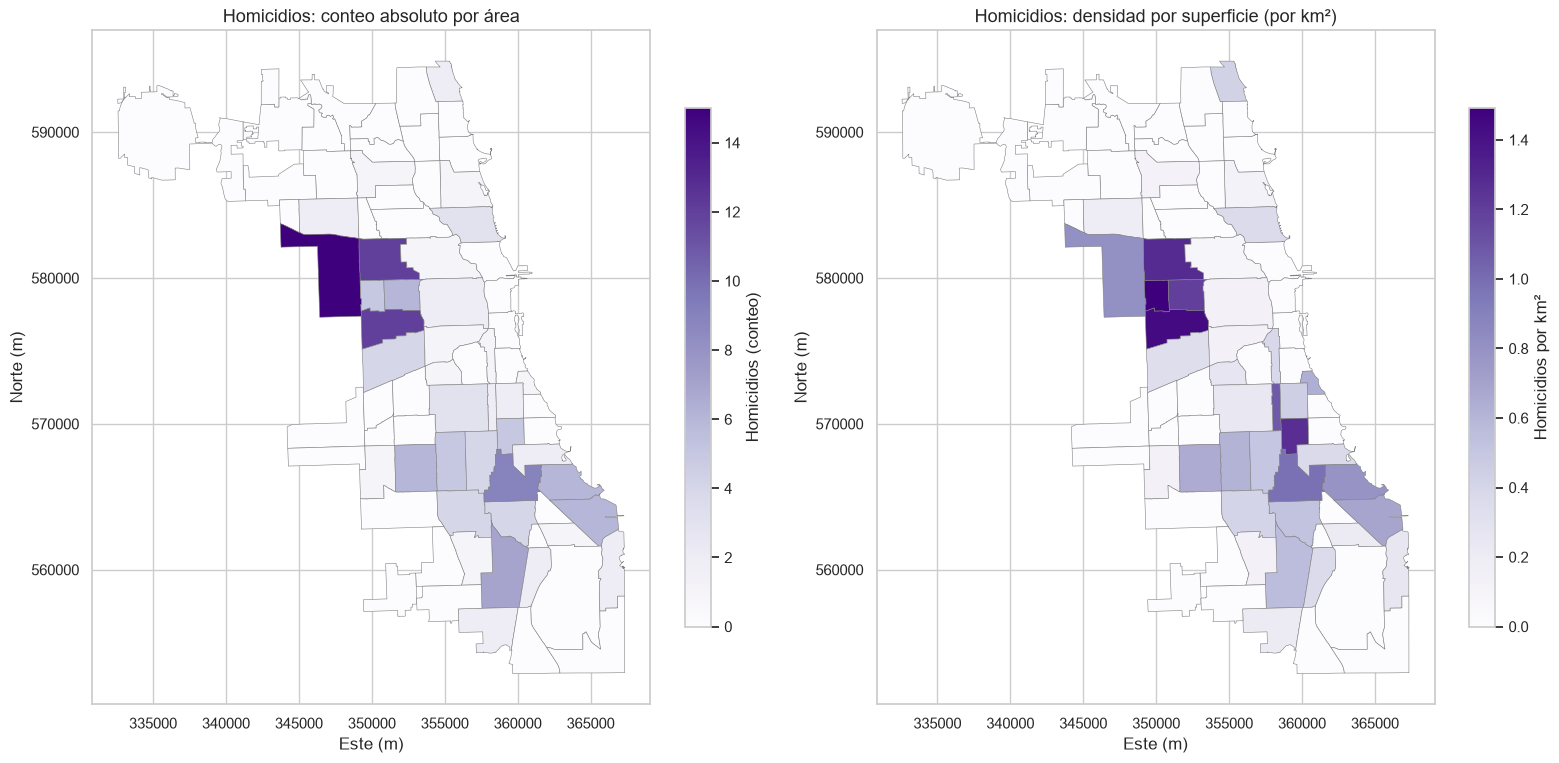

Top 5 por CONTEO de homicidios:
             community  homicidio  homi_km2
                AUSTIN         15  0.810312
         HUMBOLDT PARK         12  1.285483
        NORTH LAWNDALE         12  1.443403
GREATER GRAND CROSSING          9  0.979987
              ROSELAND          7  0.560978

Top 5 por DENSIDAD de homicidios (por km²):
         community  homicidio  homi_km2
WEST GARFIELD PARK          5  1.491136
    NORTH LAWNDALE         12  1.443403
     HUMBOLDT PARK         12  1.285483
   WASHINGTON PARK          5  1.270106
EAST GARFIELD PARK          6  1.198577

Áreas en ambos Top 5: 2 -> {'NORTH LAWNDALE', 'HUMBOLDT PARK'}

Áreas con CERO homicidios: 40 de 77


In [19]:
# ------------------------------------------------------------
# 3.3. Mapas comparativos de homicidios: conteo vs. densidad
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Conteo absoluto
areas_viz.plot(column="homicidio", ax=axes[0], legend=True, cmap="Purples",
               edgecolor="gray", linewidth=0.4,
               legend_kwds={"label": "Homicidios (conteo)", "shrink": 0.6})
axes[0].set_title("Homicidios: conteo absoluto por área", fontsize=13)
axes[0].set_xlabel("Este (m)")
axes[0].set_ylabel("Norte (m)")

# Densidad por km²
areas_viz.plot(column="homi_km2", ax=axes[1], legend=True, cmap="Purples",
               edgecolor="gray", linewidth=0.4,
               legend_kwds={"label": "Homicidios por km²", "shrink": 0.6})
axes[1].set_title("Homicidios: densidad por superficie (por km²)", fontsize=13)
axes[1].set_xlabel("Este (m)")
axes[1].set_ylabel("Norte (m)")

plt.tight_layout()
guardar_fig("05_homicidios_conteo_vs_densidad")
plt.show()

# --- ¿Cambia el ranking? ---
top5_conteo_h = areas_viz.nlargest(5, "homicidio")[["community", "homicidio", "homi_km2"]]
top5_densidad_h = areas_viz.nlargest(5, "homi_km2")[["community", "homicidio", "homi_km2"]]

print("Top 5 por CONTEO de homicidios:")
print(top5_conteo_h.to_string(index=False))
print("\nTop 5 por DENSIDAD de homicidios (por km²):")
print(top5_densidad_h.to_string(index=False))

comunes_h = set(top5_conteo_h["community"]) & set(top5_densidad_h["community"])
print(f"\nÁreas en ambos Top 5: {len(comunes_h)} -> {comunes_h}")

# Cuántas áreas tienen cero homicidios
n_cero = (areas_viz["homicidio"] == 0).sum()
print(f"\nÁreas con CERO homicidios: {n_cero} de 77")

**Análisis 3.3**

**El efecto de normalizar es mucho mayor en homicidios que en robos.** Mientras que en robos el Top 5
mantenía 4 de 5 áreas al pasar de conteo a densidad, en homicidios **solo se mantienen 2** (North
Lawndale y Humboldt Park). El caso más llamativo es **Austin**: líder indiscutido por conteo con 15
homicidios, **desaparece del Top 5 por densidad** (0,81/km²) por ser un barrio grande. En su lugar
sube **West Garfield Park**, que con apenas 5 homicidios alcanza la mayor densidad de la ciudad
(1,49/km²) por su reducido tamaño. Washington Park y East Garfield Park entran por la misma razón.

**Por qué ocurre.** Con conteos bajos, dividir por superficie amplifica el ruido: un barrio pequeño
con pocos homicidios puede saltar al primer puesto solo por su tamaño. Esta inestabilidad es una
manifestación directa de la debilidad de la evidencia: **40 de las 77 áreas (52%) no registran ningún
homicidio** en todo el verano. Cuando más de la mitad del mapa está en cero, la identificación de
áreas prioritarias se vuelve muy sensible a la métrica elegida.

**Implicación.** Para los homicidios, ni el conteo ni la densidad por barrio son procedimientos
robustos: el primero premia a los barrios grandes y el segundo a los pequeños, y ninguno captura bien
un fenómeno tan escaso y disperso a la escala de 77 unidades administrativas. Esto anticipa una ventaja
de la estimación de densidad por kernel (Paso 5): al "tomar prestada" información de las áreas vecinas
y no depender de fronteras administrativas, produce una superficie de riesgo más estable que un conteo
por barrio, aunque también más difícil de estimar con tan pocos datos.

## Paso 4. Distancia al centro

Estimamos cómo varía la intensidad del delito en función de la distancia al centro de la ciudad.
Tomando como centro las coordenadas (-87,627800; 41,881998), calculamos la distancia geodésica de cada
delito al centro y estimamos la función de densidad de esas distancias mediante KDE, seleccionando el
ancho de banda y la función de kernel por validación cruzada. Comparamos el gradiente de robos y
homicidios.

### 4.1. Cálculo de la distancia de cada delito al centro

Medimos la distancia **geodésica** (la más corta sobre el elipsoide terrestre, modelo WGS84) entre
cada delito y el centro de la ciudad, usando la función `geodesic` de `geopy`. Trabajamos con
coordenadas geográficas (lat, lon) en grados; `geodesic` calcula internamente la distancia sobre el
elipsoide, por lo que el resultado queda expresado en **kilómetros**.

In [20]:
# ------------------------------------------------------------
# 4.1. Distancia geodésica de cada delito al centro de Chicago
# ------------------------------------------------------------

# Centro de la ciudad definido en el enunciado (lon, lat)
CENTRO_LON = -87.627800
CENTRO_LAT = 41.881998
centro = (CENTRO_LAT, CENTRO_LON)   # geopy espera (lat, lon)

# Distancia geodésica en km para cada delito
delitos["dist_centro_km"] = delitos.apply(
    lambda fila: geodesic(centro, (fila["lat"], fila["lon"])).km,
    axis=1,
)

print("Distancia al centro (km) — todos los delitos:")
print(delitos["dist_centro_km"].describe())

print("\nPor tipo de crimen:")
print(delitos.groupby("tipo_crimen")["dist_centro_km"]
      .agg(["count", "mean", "std", "min", "max"]))

Distancia al centro (km) — todos los delitos:
count    17747.000000
mean         9.017958
std          5.992482
min          0.023621
25%          3.891877
50%          8.674172
75%         13.384658
max         27.285786
Name: dist_centro_km, dtype: float64

Por tipo de crimen:
             count       mean       std       min        max
tipo_crimen                                                 
homicidio      144  11.458908  4.386565  3.060514  22.659096
robo         17603   8.997990  5.999846  0.023621  27.285786


**Análisis 4.1**

Las distancias al centro tienen rangos coherentes con la extensión de Chicago (de casi 0 a 27 km).
La comparación por tipo de delito confirma el patrón espacial detectado en los pasos anteriores:

- Los **robos** están, en promedio, a **9,0 km** del centro, y el más cercano ocurre a apenas 24
  metros: son un fenómeno del núcleo urbano.
- Los **homicidios** están más lejos, a **11,5 km** en promedio, y ninguno ocurre a menos de 3 km del
  centro.

Esta diferencia de más de 2 km en la distancia media anticipa que los gradientes de densidad de ambos
delitos serán distintos: el de robos debería concentrarse cerca del centro y el de homicidios,
desplazarse hacia la periferia. Lo verificamos estimando las densidades por KDE.

### 4.2. Selección de ancho de banda y kernel por validación cruzada

Para cada tipo de delito buscamos el mejor ancho de banda y la mejor función de kernel mediante
validación cruzada, evaluando una grilla de anchos de banda y las cuatro funciones de kernel
(gaussiano, Epanechnikov, tophat y lineal). El criterio de selección es la **log-verosimilitud**: la
combinación que maximiza la verosimilitud fuera de muestra es la que mejor describe los datos sin
sobreajustar. Realizamos la búsqueda por separado para robos y homicidios, ya que sus distribuciones
difieren.

In [21]:
# ------------------------------------------------------------
# 4.2. Validación cruzada del ancho de banda y el kernel
# ------------------------------------------------------------

def seleccionar_kde(distancias, nombre, cv=5):
    """Selecciona (bandwidth, kernel) por validación cruzada maximizando
    la log-verosimilitud. Devuelve el objeto GridSearchCV ajustado."""
    vals = distancias.to_numpy().reshape(-1, 1)

    # Grilla de anchos de banda (en km), en escala logarítmica
    bandwidths = 10 ** np.linspace(-1, 1, 30)   # de 0.1 a 10 km

    param_grid = {
        "bandwidth": bandwidths,
        "kernel": ["gaussian", "epanechnikov", "tophat", "linear"],
    }

    grid = GridSearchCV(
        KernelDensity(),
        param_grid=param_grid,
        cv=cv,
    )
    grid.fit(vals)

    print(f"--- {nombre} (n={len(vals)}) ---")
    print(f"  Mejor kernel:       {grid.best_params_['kernel']}")
    print(f"  Mejor ancho banda:  {grid.best_params_['bandwidth']:.3f} km")
    print(f"  Log-verosimilitud:  {grid.best_score_:.3f}")
    print()
    return grid

# Robos
dist_robos = delitos.loc[delitos["tipo_crimen"] == "robo", "dist_centro_km"]
grid_robos = seleccionar_kde(dist_robos, "ROBOS")

# Homicidios
dist_homi = delitos.loc[delitos["tipo_crimen"] == "homicidio", "dist_centro_km"]
grid_homi = seleccionar_kde(dist_homi, "HOMICIDIOS")

--- ROBOS (n=17603) ---
  Mejor kernel:       linear
  Mejor ancho banda:  0.117 km
  Log-verosimilitud:  -10635.906

--- HOMICIDIOS (n=144) ---
  Mejor kernel:       tophat
  Mejor ancho banda:  0.924 km
  Log-verosimilitud:  -82.704



### 4.3. Gradiente de densidad: robos vs. homicidios

Graficamos la densidad estimada de la distancia al centro para cada delito, usando el kernel y el ancho
de banda seleccionados por validación cruzada. La densidad muestra a qué distancias del centro se
concentra cada tipo de delito.

Figura guardada en: output\06_gradiente_distancia_cv.png


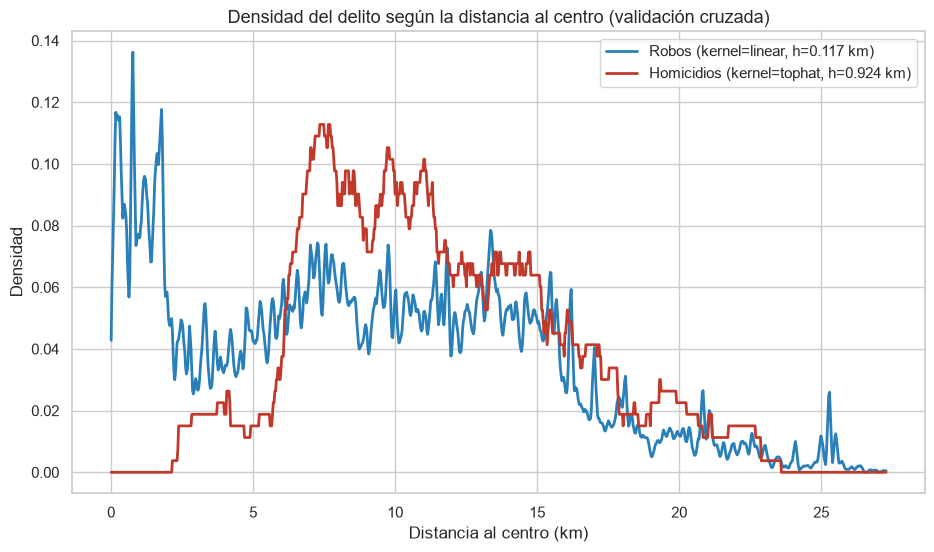

In [22]:
# ------------------------------------------------------------
# 4.3. Gráfico de las densidades estimadas (h de validación cruzada)
# ------------------------------------------------------------

def densidad_estimada(grid, x_grid):
    """Evalúa la densidad del mejor estimador de un GridSearchCV."""
    log_dens = grid.best_estimator_.score_samples(x_grid.reshape(-1, 1))
    return np.exp(log_dens)

# Rango de distancias sobre el que evaluamos (de 0 al máximo observado)
x_grid = np.linspace(0, delitos["dist_centro_km"].max(), 1000)

dens_robos = densidad_estimada(grid_robos, x_grid)
dens_homi = densidad_estimada(grid_homi, x_grid)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(x_grid, dens_robos, color="#2980b9", linewidth=2,
        label=f"Robos (kernel={grid_robos.best_params_['kernel']}, "
              f"h={grid_robos.best_params_['bandwidth']:.3f} km)")
ax.plot(x_grid, dens_homi, color="#c0392b", linewidth=2,
        label=f"Homicidios (kernel={grid_homi.best_params_['kernel']}, "
              f"h={grid_homi.best_params_['bandwidth']:.3f} km)")

ax.set_title("Densidad del delito según la distancia al centro (validación cruzada)",
             fontsize=13)
ax.set_xlabel("Distancia al centro (km)")
ax.set_ylabel("Densidad")
ax.legend()

guardar_fig("06_gradiente_distancia_cv")
plt.show()

### 4.4. Análisis de sensibilidad al ancho de banda

La validación cruzada por log-verosimilitud seleccionó anchos de banda muy pequeños (0,117 km para
robos), que producen densidades con mucho ruido, difíciles de interpretar para una decisión operativa.
Este comportamiento es conocido: con muestras grandes, la validación cruzada por verosimilitud tiende a
sub-suavizar. Para evaluar la sensibilidad de los resultados, comparamos el ancho de banda de la
validación cruzada con las reglas plug-in de Scott y Silverman, que asumen una distribución de
referencia y producen estimaciones más suaves.

--- ROBOS ---
  h validación cruzada: 0.117 km
  h Scott:              0.900 km
  h Silverman:          0.764 km

Figura guardada en: output\07_sensibilidad_robos.png


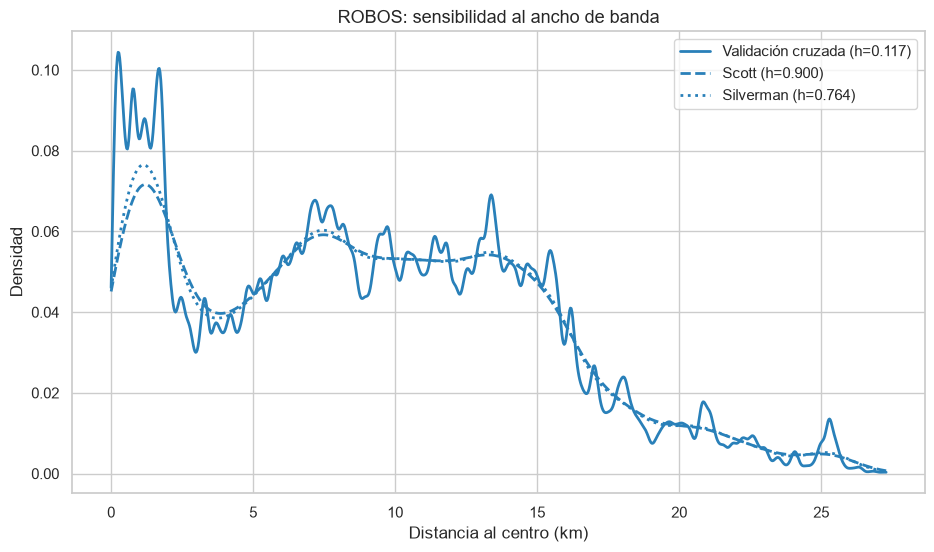

--- HOMICIDIOS ---
  h validación cruzada: 0.924 km
  h Scott:              1.721 km
  h Silverman:          1.461 km

Figura guardada en: output\08_sensibilidad_homicidios.png


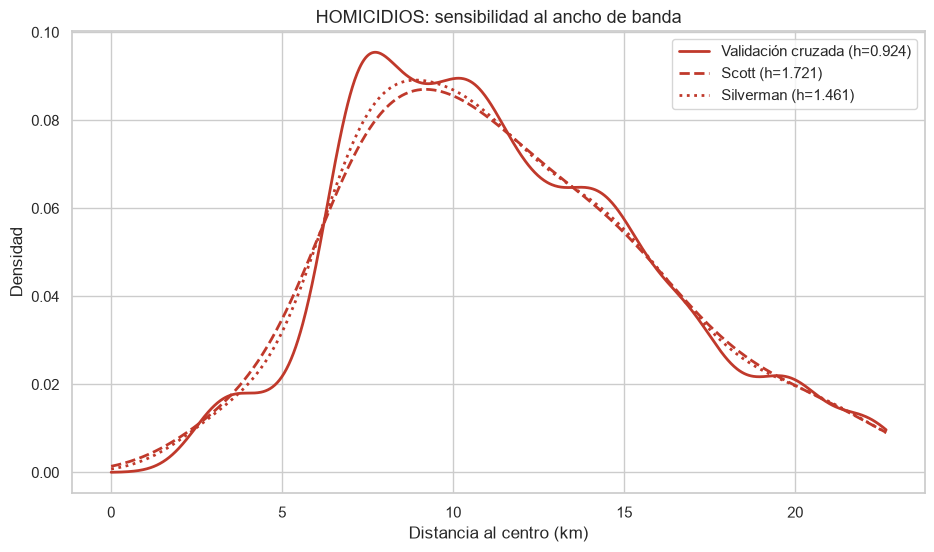

In [23]:
# ------------------------------------------------------------
# 4.4. Sensibilidad: validación cruzada vs. Scott vs. Silverman
# ------------------------------------------------------------

def regla_scott(x):
    n = len(x)
    return 1.06 * np.std(x, ddof=1) * n ** (-1/5)

def regla_silverman(x):
    n = len(x)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    return 0.9 * min(np.std(x, ddof=1), iqr / 1.34) * n ** (-1/5)

def graficar_sensibilidad(distancias, grid_cv, nombre, color_base, archivo):
    x = distancias.to_numpy()
    x_grid = np.linspace(0, x.max(), 1000)

    h_cv = grid_cv.best_params_["bandwidth"]
    h_scott = regla_scott(x)
    h_silver = regla_silverman(x)

    print(f"--- {nombre} ---")
    print(f"  h validación cruzada: {h_cv:.3f} km")
    print(f"  h Scott:              {h_scott:.3f} km")
    print(f"  h Silverman:          {h_silver:.3f} km")
    print()

    fig, ax = plt.subplots(figsize=(11, 6))
    for h, estilo, etiqueta in [
        (h_cv, "-", f"Validación cruzada (h={h_cv:.3f})"),
        (h_scott, "--", f"Scott (h={h_scott:.3f})"),
        (h_silver, ":", f"Silverman (h={h_silver:.3f})"),
    ]:
        # Usamos kernel gaussiano para comparar solo el efecto del ancho de banda
        kde = KernelDensity(bandwidth=h, kernel="gaussian").fit(x.reshape(-1, 1))
        dens = np.exp(kde.score_samples(x_grid.reshape(-1, 1)))
        ax.plot(x_grid, dens, estilo, color=color_base, linewidth=2, label=etiqueta)

    ax.set_title(f"{nombre}: sensibilidad al ancho de banda", fontsize=13)
    ax.set_xlabel("Distancia al centro (km)")
    ax.set_ylabel("Densidad")
    ax.legend()
    guardar_fig(archivo)
    plt.show()

graficar_sensibilidad(dist_robos, grid_robos, "ROBOS", "#2980b9",
                      "07_sensibilidad_robos")
graficar_sensibilidad(dist_homi, grid_homi, "HOMICIDIOS", "#c0392b",
                      "08_sensibilidad_homicidios")

**Análisis Paso 4**

**Qué selecciona la validación cruzada.** Para robos elige kernel *lineal* con h = 0,117 km; para
homicidios, kernel *tophat* con h = 0,924 km. En ambos casos el ancho de banda es menor que el de las
reglas plug-in (Scott y Silverman), lo que produce densidades con ruido. Este sub-suavizado es un
comportamiento conocido de la validación cruzada por verosimilitud con muestras grandes: al premiar el
ajuste dentro de muestra, tiende a pegarse a los datos.

**Sensibilidad al ancho de banda.** El efecto de la elección de h **depende del tamaño de la muestra**:

- En **robos** (17.603 datos), la diferencia es grande: la validación cruzada (0,117 km) genera una
  curva muy dentada, mientras que Scott (0,900) y Silverman (0,764) —casi idénticas entre sí— producen
  una curva suave. Sin embargo, el patrón de fondo es el mismo: la curva ruidosa oscila alrededor de la
  suave. Para comunicar el resultado conviene el ancho de banda mayor.
- En **homicidios** (144 datos), las tres reglas convergen: la forma de la densidad es estable
  independientemente del h elegido. Con pocos datos, no hay suficiente detalle que sub-suavizar.

**Gradientes distintos.** El resultado sustantivo es robusto a la elección de h:
- Los **robos** tienen un pico pronunciado en el **centro (0-2 km)** y una meseta secundaria en la
  franja media (7-15 km). No decaen de forma monótona.
- Los **homicidios** son casi nulos en los primeros 3-4 km y se concentran en un **anillo intermedio
  (7-11 km)**, lejos del centro.

**Supuestos y utilidad.** Representar el delito como función de la distancia al centro impone un
supuesto fuerte de **simetría radial**: asume que lo único que importa es la distancia al centro, no la
dirección. Esto colapsa la ciudad en un solo eje y pierde información direccional —no distingue el
oeste del sur, aunque el Paso 2 mostró que la violencia se concentra en ambos. Es útil como diagnóstico
del gradiente centro-periferia y confirma que robos y homicidios ocupan anillos distintos, pero **no
sirve para señalar lugares concretos de patrullaje**: un anillo a 8 km del centro abarca decenas de
barrios en todas las direcciones. Para localizar puntos calientes se requiere la densidad bivariada
(Paso 5), que conserva las dos dimensiones del espacio.

**Decisión metodológica.** Para la interpretación y la comunicación adoptamos un ancho de banda tipo
Scott/Silverman, que revela el patrón sin el ruido de la validación cruzada, dejando constancia de que
la elección de h afecta la apariencia pero no las conclusiones sustantivas.